# Nowcasting Espaço-Temporal de Inundações Urbanas com U-RNN (demo funcional)

**Pedro Henrique Nunes Zanette**
**Americas TechGuard | Período 7** — Implementação Funcional de Nowcasting Espaço-Temporal de Inundações Urbanas com U-RNN

Este notebook reproduz, de forma narrativa e executável, o mesmo pipeline funcional disponível em `src/`. Ele gera dados, treina o modelo `URNNLite` (inspirado no U-RNN) e exibe todas as evidências de funcionamento.

## Objetivo

Demonstrar uma solução **funcional, reduzida e verificável** de nowcasting espaço-temporal de inundações urbanas, inspirada na arquitetura do modelo **U-RNN**, usando dados sintéticos tecnicamente justificados (dataset oficial de ~116 GB extraído não pôde ser extraído integralmente por limitação de armazenamento — ver seção "Dados utilizados").

## Referências obrigatórias

- **Artigo científico:** [U-RNN: high-resolution spatiotemporal nowcasting of urban flooding](https://www.sciencedirect.com/science/article/pii/S002216942500455X)
- **Material suplementar / dataset (Figshare):** [Supplementary data of U-RNN](https://figshare.com/articles/dataset/Supplementary_data_of_U-RNN_high-resolution_spatiotemporal_nowcasting_of_urban_flooding_/28082549?file=51407804)
- **GitHub oficial:** [holmescao/U-RNN](https://github.com/holmescao/U-RNN)

Esses três materiais guiaram: (1) o entendimento do problema, entradas/saídas e arquitetura conceitual do U-RNN; (2) a estrutura geral de um pipeline de nowcasting em PyTorch; (3) a origem do dataset oficial, baixado em `data/raw/urbanflood24_api.zip` e auditado (sem extração completa) por `src/inspect_zip.py`.

## Conceitos

**Nowcasting de inundações urbanas**: predição de curto prazo da evolução espaço-temporal de uma inundação, a partir de chuva recente, terreno e estados hidrológicos observados/simulados.

**Diferença para suscetibilidade**: suscetibilidade é um mapa **estático** de onde inundação é fisicamente mais provável (terreno, drenagem, uso do solo). Nowcasting tem dimensão **temporal explícita**: prediz como o evento evolui minuto a minuto / passo a passo.

**Diferença para risco**: risco combina exposição, vulnerabilidade, população, infraestrutura crítica e impactos potenciais — vai muito além da profundidade de água prevista. **Esta entrega não é um modelo de risco.**

**U-like / ConvGRU**: arquitetura em formato "U" (como U-Net) — encoder convolucional extrai características espaciais, decoder convolucional reconstrói o mapa de saída, com blocos recorrentes convolucionais (ConvGRU/ConvLSTM) para capturar a evolução temporal. A recorrência mantém um **estado espacial** (mapa H×W), não um vetor.

**Sliding Window-based Pre-warming**: uma janela deslizante de passos passados é usada **apenas para inicializar (aquecer)** o estado oculto da rede recorrente, antes de começar a gerar as predições futuras — evita partir de um estado zerado/arbitrário.

## Dados utilizados

- **Dataset oficial** (Figshare, U-RNN supplementary data): baixado e mantido em `data/raw/urbanflood24_api.zip` (~18 GB compactado / ~116 GB extraído). **Não foi extraído integralmente** por limitação de armazenamento em disco local. Foi inspecionado sem extração via `src/inspect_zip.py` (índice do ZIP, extensões, tamanhos) — ver `outputs/zip_inventory.txt`.
- **Dados sintéticos/reduzidos** (`src/synthetic_data.py`): gerados deterministicamente (seed fixa) simulando terreno com declividade e depressões, máscara de impermeabilidade/urbanização, chuva variável no tempo, e uma sequência de profundidade de inundação evoluindo por um esquema simplificado de fonte + roteamento gravitacional + infiltração.

**Justificativa técnica**: o enunciado oficial da atividade permite explicitamente dados sintéticos justificados quando o dataset completo é inviável computacionalmente, desde que a solução final execute e gere saídas verificáveis — que é exatamente o caminho adotado aqui.

## Execução

As células abaixo importam os módulos de `src/`, geram o dataset sintético, treinam o modelo `URNNLite` (ConvGRU-based, inspirado no U-RNN) e reproduzem o pipeline completo de `src/train_demo.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"Project root (relativo ao notebook): {PROJECT_ROOT.name}/")


Project root (relativo ao notebook): urbanflood_urnn_demo/


In [2]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

from synthetic_data import SyntheticDatasetConfig, generate_synthetic_dataset
from model import URNNLite
from visualize import save_all_outputs

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__}")


Dispositivo: cuda
PyTorch: 2.12.1+cu130


In [3]:
# Gerar dataset sintetico (mesmos parametros de src/train_demo.py)
config = SyntheticDatasetConfig(n_samples=60, height=64, width=64, t_in=5, t_out=5, seed=42)
X, y, meta = generate_synthetic_dataset(config)
print(f"X shape: {X.shape}  (N, T_in, C, H, W)")
print(f"y shape: {y.shape}  (N, T_out, 1, H, W)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")


X shape: (60, 5, 4, 64, 64)  (N, T_in, C, H, W)
y shape: (60, 5, 1, 64, 64)  (N, T_out, 1, H, W)
Treino: 45 amostras | Teste: 15 amostras


In [4]:
X_train_t = torch.from_numpy(X_train).float().to(device)
y_train_t = torch.from_numpy(y_train).float().to(device)
X_test_t = torch.from_numpy(X_test).float().to(device)
y_test_t = torch.from_numpy(y_test).float().to(device)

model = URNNLite(in_channels=X.shape[2], base_channels=16, hidden_channels=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo: URNNLite (ConvGRU) | parametros treinaveis: {n_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


Modelo: URNNLite (ConvGRU) | parametros treinaveis: 54,017


In [5]:
EPOCHS = 25
BATCH_SIZE = 8
losses = []
n_train = X_train_t.shape[0]

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    perm = np.random.permutation(n_train)
    for start in range(0, n_train, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        xb, yb = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        pred = model(xb, t_out=config.t_out)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    mean_loss = float(np.mean(epoch_losses))
    losses.append(mean_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoca {epoch:02d}/{EPOCHS} | MSE treino: {mean_loss:.5f}")


Epoca 01/25 | MSE treino: 0.01458


Epoca 05/25 | MSE treino: 0.00682


Epoca 10/25 | MSE treino: 0.00486


Epoca 15/25 | MSE treino: 0.00442


Epoca 20/25 | MSE treino: 0.00462


Epoca 25/25 | MSE treino: 0.00495


In [6]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t, t_out=config.t_out)
    test_mse = criterion(test_pred, y_test_t).item()
    test_mae = torch.mean(torch.abs(test_pred - y_test_t)).item()

print(f"MSE final (teste): {test_mse:.5f}")
print(f"MAE final (teste): {test_mae:.5f}")


MSE final (teste): 0.00529
MAE final (teste): 0.05757


In [7]:
# Predicao em uma sequencia de teste para visualizacao
sample_idx = 0
with torch.no_grad():
    single_input = X_test_t[sample_idx:sample_idx + 1]
    single_pred = model(single_input, t_out=config.t_out).cpu().numpy()[0, :, 0]

input_seq_vis = X_test[sample_idx, :, 0]
target_seq_vis = y_test[sample_idx, :, 0]
pred_seq_vis = single_pred

output_dir = PROJECT_ROOT / "outputs"
save_all_outputs(input_seq_vis, target_seq_vis, pred_seq_vis, losses, output_dir)
print(f"Evidencias salvas em: outputs/ (relative to project root)")


Evidencias salvas em: outputs/ (relative to project root)


## Evidências

As imagens e o GIF abaixo são gerados pelo pipeline acima (ou pela última execução de `python src/train_demo.py`) e salvos em `outputs/`.

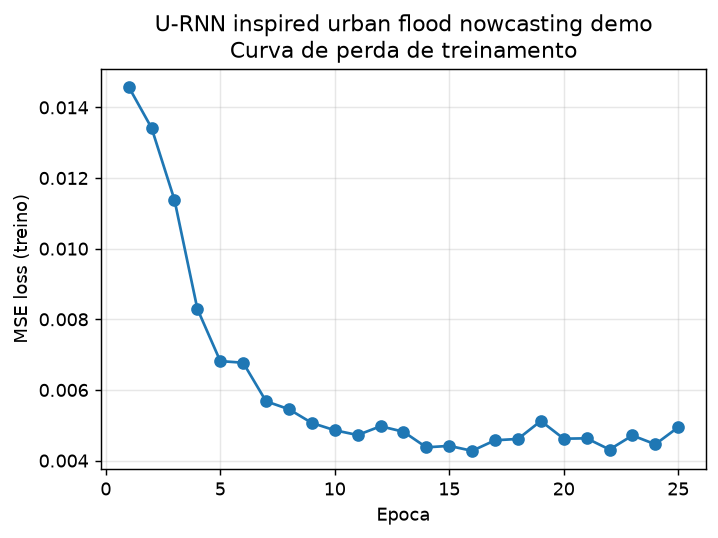

In [8]:
from IPython.display import Image, display, JSON
import json

display(Image(filename=str(output_dir / "loss_curve.png")))


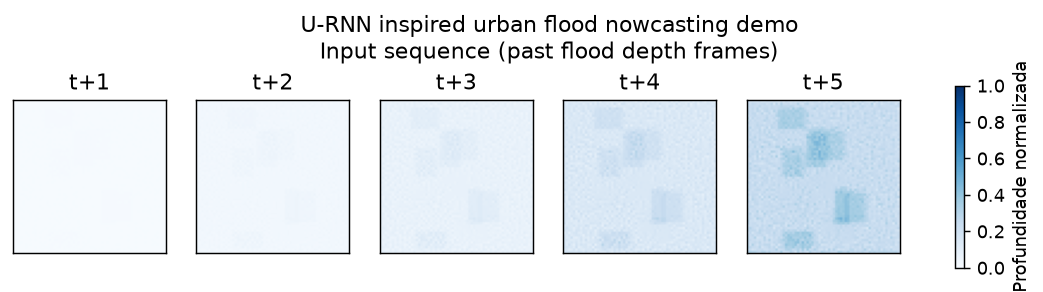

In [9]:
display(Image(filename=str(output_dir / "input_sequence.png")))


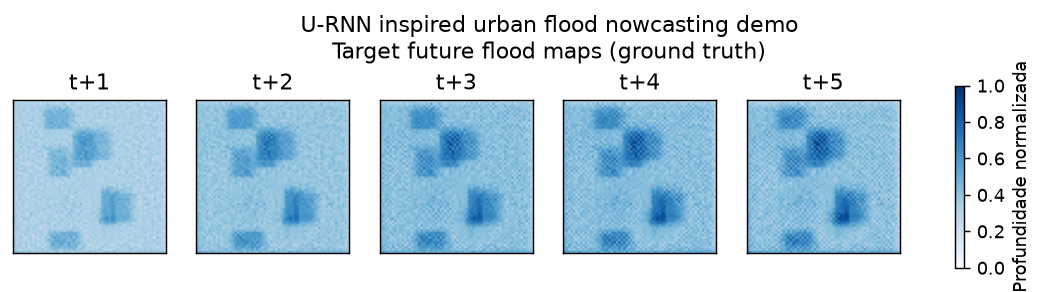

In [10]:
display(Image(filename=str(output_dir / "target_sequence.png")))


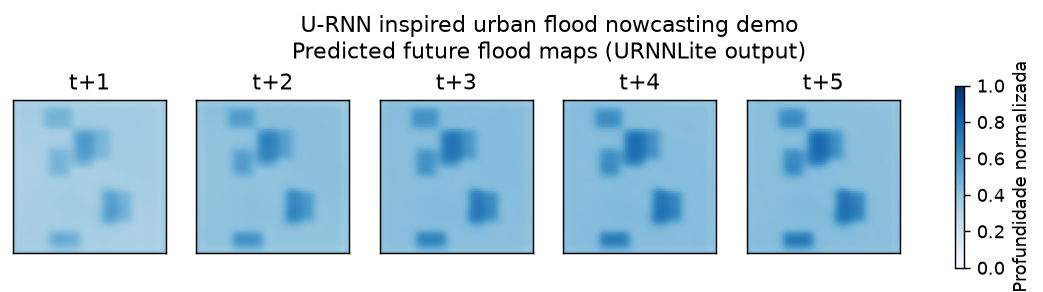

In [11]:
display(Image(filename=str(output_dir / "prediction_sequence.png")))


GIF animado comparando entrada (contexto), alvo real e predição, quadro a quadro: `outputs/flood_nowcasting.gif`

![flood nowcasting gif](../outputs/flood_nowcasting.gif)

In [12]:
with open(output_dir / "metrics.json") as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))


{
  "dataset": {
    "n_samples": 60,
    "grid_size": 64,
    "t_in": 5,
    "t_out": 5,
    "n_train": 45,
    "n_test": 15,
    "seed": 42,
    "source": "synthetic (src/synthetic_data.py) - dataset oficial nao extraido integralmente (ver data/README.md)"
  },
  "model": {
    "name": "URNNLite (ConvGRU-based, U-RNN inspired)",
    "n_parameters": 54017,
    "device": "cuda"
  },
  "training": {
    "epochs": 25,
    "batch_size": 8,
    "learning_rate": 0.001,
    "final_train_mse": 0.0049447740117708845,
    "loss_curve": [
      0.014581576765825352,
      0.013417679506043593,
      0.011381302184114853,
      0.008295529056340456,
      0.006817349465563893,
      0.006770862266421318,
      0.005679243166620533,
      0.005454492522403598,
      0.005066300431887309,
      0.004859581822529435,
      0.004724415251985192,
      0.004972498941545685,
      0.0048180284987514215,
      0.004376353230327368,
      0.004417092151318987,
      0.0042771283381929,
      0.0045760832

## Limitações

- Dados sintéticos não substituem validação com dados reais de campo.
- Não há calibração hidrológica local (sem chuva/topografia reais de uma bacia urbana específica).
- Não há sensores reais de nível d'água nem validação hidrodinâmica (comparação com um solver físico, ex.: Saint-Venant 2D).
- O dataset oficial do U-RNN (Figshare) não foi extraído integralmente por limitação de armazenamento (~116 GB); apenas seu índice foi inspecionado (`src/inspect_zip.py`, `outputs/zip_inventory.txt`).
- O modelo `URNNLite` é demonstrativo e inspirado no U-RNN — não reproduz a arquitetura, o treinamento nem os resultados do artigo original.
- O esquema de propagação de água no gerador sintético é uma aproximação simplificada (roteamento gravitacional local), não um solver hidrodinâmico validado.

## Aplicação ao Americas TechGuard

Uma solução de nowcasting como esta poderia apoiar o Americas TechGuard em:

- **Monitoramento contínuo**: previsões de curtíssimo prazo da evolução de um evento de inundação em curso.
- **Prevenção e resposta**: antecipar áreas que devem inundar nos próximos passos de tempo, priorizando resposta operacional antes do pico do evento.
- **Geração de alertas**: alimentar um sistema de alerta automatizado com mapas de profundidade prevista, em vez de depender apenas de limiares estáticos de suscetibilidade.

**Integrações futuras possíveis**: chuva real (radar/pluviômetros), sensores de nível d'água, imagens de satélite/DSM de alta resolução, geoprocessamento (drenagem real, uso do solo), dashboards de monitoramento e disseminação automática de alertas.

**Diferença entre esta prova didática e uma PoC robusta**: esta entrega demonstra a arquitetura e o fluxo de dados com dados sintéticos e em escala reduzida. Uma PoC robusta para uso real exigiria o dataset oficial completo (ou dados reais equivalentes), validação hidrodinâmica, calibração local, testes de generalização entre bacias urbanas distintas, e avaliação de risco associada (exposição, vulnerabilidade, população, infraestrutura crítica) — fora do escopo desta atividade.